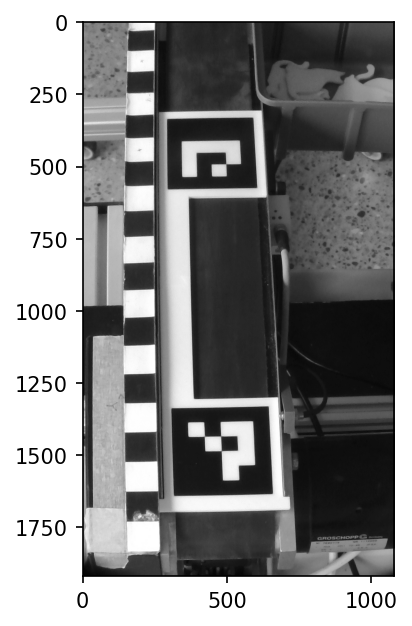

In [14]:
import cv2 as cv
from cv2 import aruco
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))

# Bild einlesen und formatieren
img = cv.imread("aruco_pic/aruco_0.png")
img_rotated = cv.rotate(img, 2)
cv.imwrite(img=img_rotated, filename='rotated.png')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_rotated = cv.rotate(gray, 2)

fig = plt.imshow(gray_rotated, cmap = 'gray', vmin=0, vmax=255)

In [15]:
corners, ids, rejected = detector.detectMarkers(gray_rotated)

pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])
pts1, corners

(array([[ 292.,  339.],
        [ 589.,  335.],
        [ 314., 1640.],
        [ 656., 1636.]], dtype=float32),
 (array([[[ 307., 1340.],
          [ 642., 1333.],
          [ 656., 1636.],
          [ 314., 1640.]]], dtype=float32),
  array([[[292., 339.],
          [589., 335.],
          [601., 578.],
          [293., 581.]]], dtype=float32)))

(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

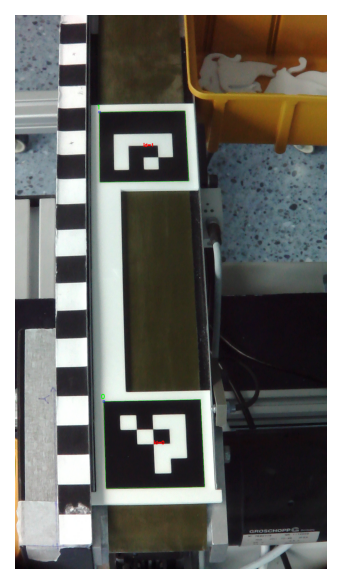

In [16]:
# Marker anzeichnen

if len(ids) > 0:
    img_markers = img_rotated.copy()
    aruco.drawDetectedMarkers(img_markers, corners, ids)
    
    for i, corner in enumerate(corners):
        top_left = corner[0][0]  # corner[marker][punkt][x/y]
        cv.putText(img_markers, str(ids[i][0]),
                   (int(top_left[0]) - 10, int(top_left[1]) - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    #cv.imshow("Detected Markers", img_markers)
    #cv.waitKey(0)
    #cv.destroyAllWindows()
else:
    print("Keine Marker erkannt!")

fig = plt.imshow(img_markers, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')

In [17]:
dstPoints = np.concatenate(corners, axis=1)

H, status = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H, status

(array([[ 5.95941354e+00,  9.74525553e-02,  2.93982305e+02],
        [-5.03797130e-02, -3.92396627e+00,  1.56714562e+03],
        [ 2.06574044e-04,  3.68561046e-04,  1.00000000e+00]]),
 array([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0]], dtype=uint8))

In [18]:
pixel_cam = np.array([[[283.0, 451.0]]], dtype=np.float32)
world = cv.perspectiveTransform(pixel_cam, H)
X, Y = world[0,0,0], world[0,0,1]

In [19]:
H_inv = np.linalg.inv(H)
world_inv = cv.perspectiveTransform(pixel_cam, H_inv)
world_inv, H_inv, H

(array([[[ -1.5442624, 272.93793  ]]], dtype=float32),
 array([[ 1.69503301e-01, -4.10352646e-04, -4.91878889e+01],
        [-1.40869328e-02, -2.22111351e-01,  3.52222140e+02],
        [-2.98230877e-05,  8.19463600e-05,  8.80345581e-01]]),
 array([[ 5.95941354e+00,  9.74525553e-02,  2.93982305e+02],
        [-5.03797130e-02, -3.92396627e+00,  1.56714562e+03],
        [ 2.06574044e-04,  3.68561046e-04,  1.00000000e+00]]))